# Unit 4 End Project
## Home Loan Data Analysis

In [1]:
%pip install seaborn
%pip install scikit-learn
%pip install pandas


Fri Mar 27 18:04:09 CDT 2026

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: /proj/ksims/Classwork_ml/RNNs/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Fri Mar 27 18:04:11 CDT 2026

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: /proj/ksims/Classwork_ml/RNNs/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Fri Mar 27 18:04:13 CDT 2026

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: /proj/ksims/Classwork_ml/RNNs/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
import re
import pandas as pd

import DataProcessing as dp

In [3]:
processor = dp.DataProcessing()
processor.loadFrom_CSV("../data/Lending_Club.csv")
processor.set_target("credit.policy")
print(processor.get_data().info())


<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB
None


In [4]:
# Encode non-numeric (Object) columns
excludeList = []
processor.encodeObjectDataTypes(excluded_parameters=excludeList)
print(processor.get_info())
#print(processor.get_data().head())

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.0 MB
None


In [5]:
# Update numeric data types
processor.processNumericDataTypes()
print(processor.get_info())

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int8   
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float32
 3   installment        9578 non-null   float32
 4   log.annual.inc     9578 non-null   float32
 5   dti                9578 non-null   float32
 6   fico               9578 non-null   int16  
 7   days.with.cr.line  9578 non-null   float32
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float32
 10  inq.last.6mths     9578 non-null   int8   
 11  delinq.2yrs        9578 non-null   int8   
 12  pub.rec            9578 non-null   int8   
 13  not.fully.paid     9578 non-null   int8   
dtypes: float32(6), int16(1), int64(1), int8(5), str(1)
memory usage: 439.7 KB
None


In [6]:
# Process Date Fields
#processor.encodeDateTimeParameters("release_date",format="%Y-%m-%d")
#print(processor.get_info())
#print(processor.get_data().head())

In [7]:
# Check for missing data

missing_data = processor.locateMissingData()

if len(missing_data) == 0 :
    print("No missing data was detected.")
else:
    key_list = list(missing_data.keys())
    tmp_df = processor.getMissingValues(key_list)


No missing data was detected.


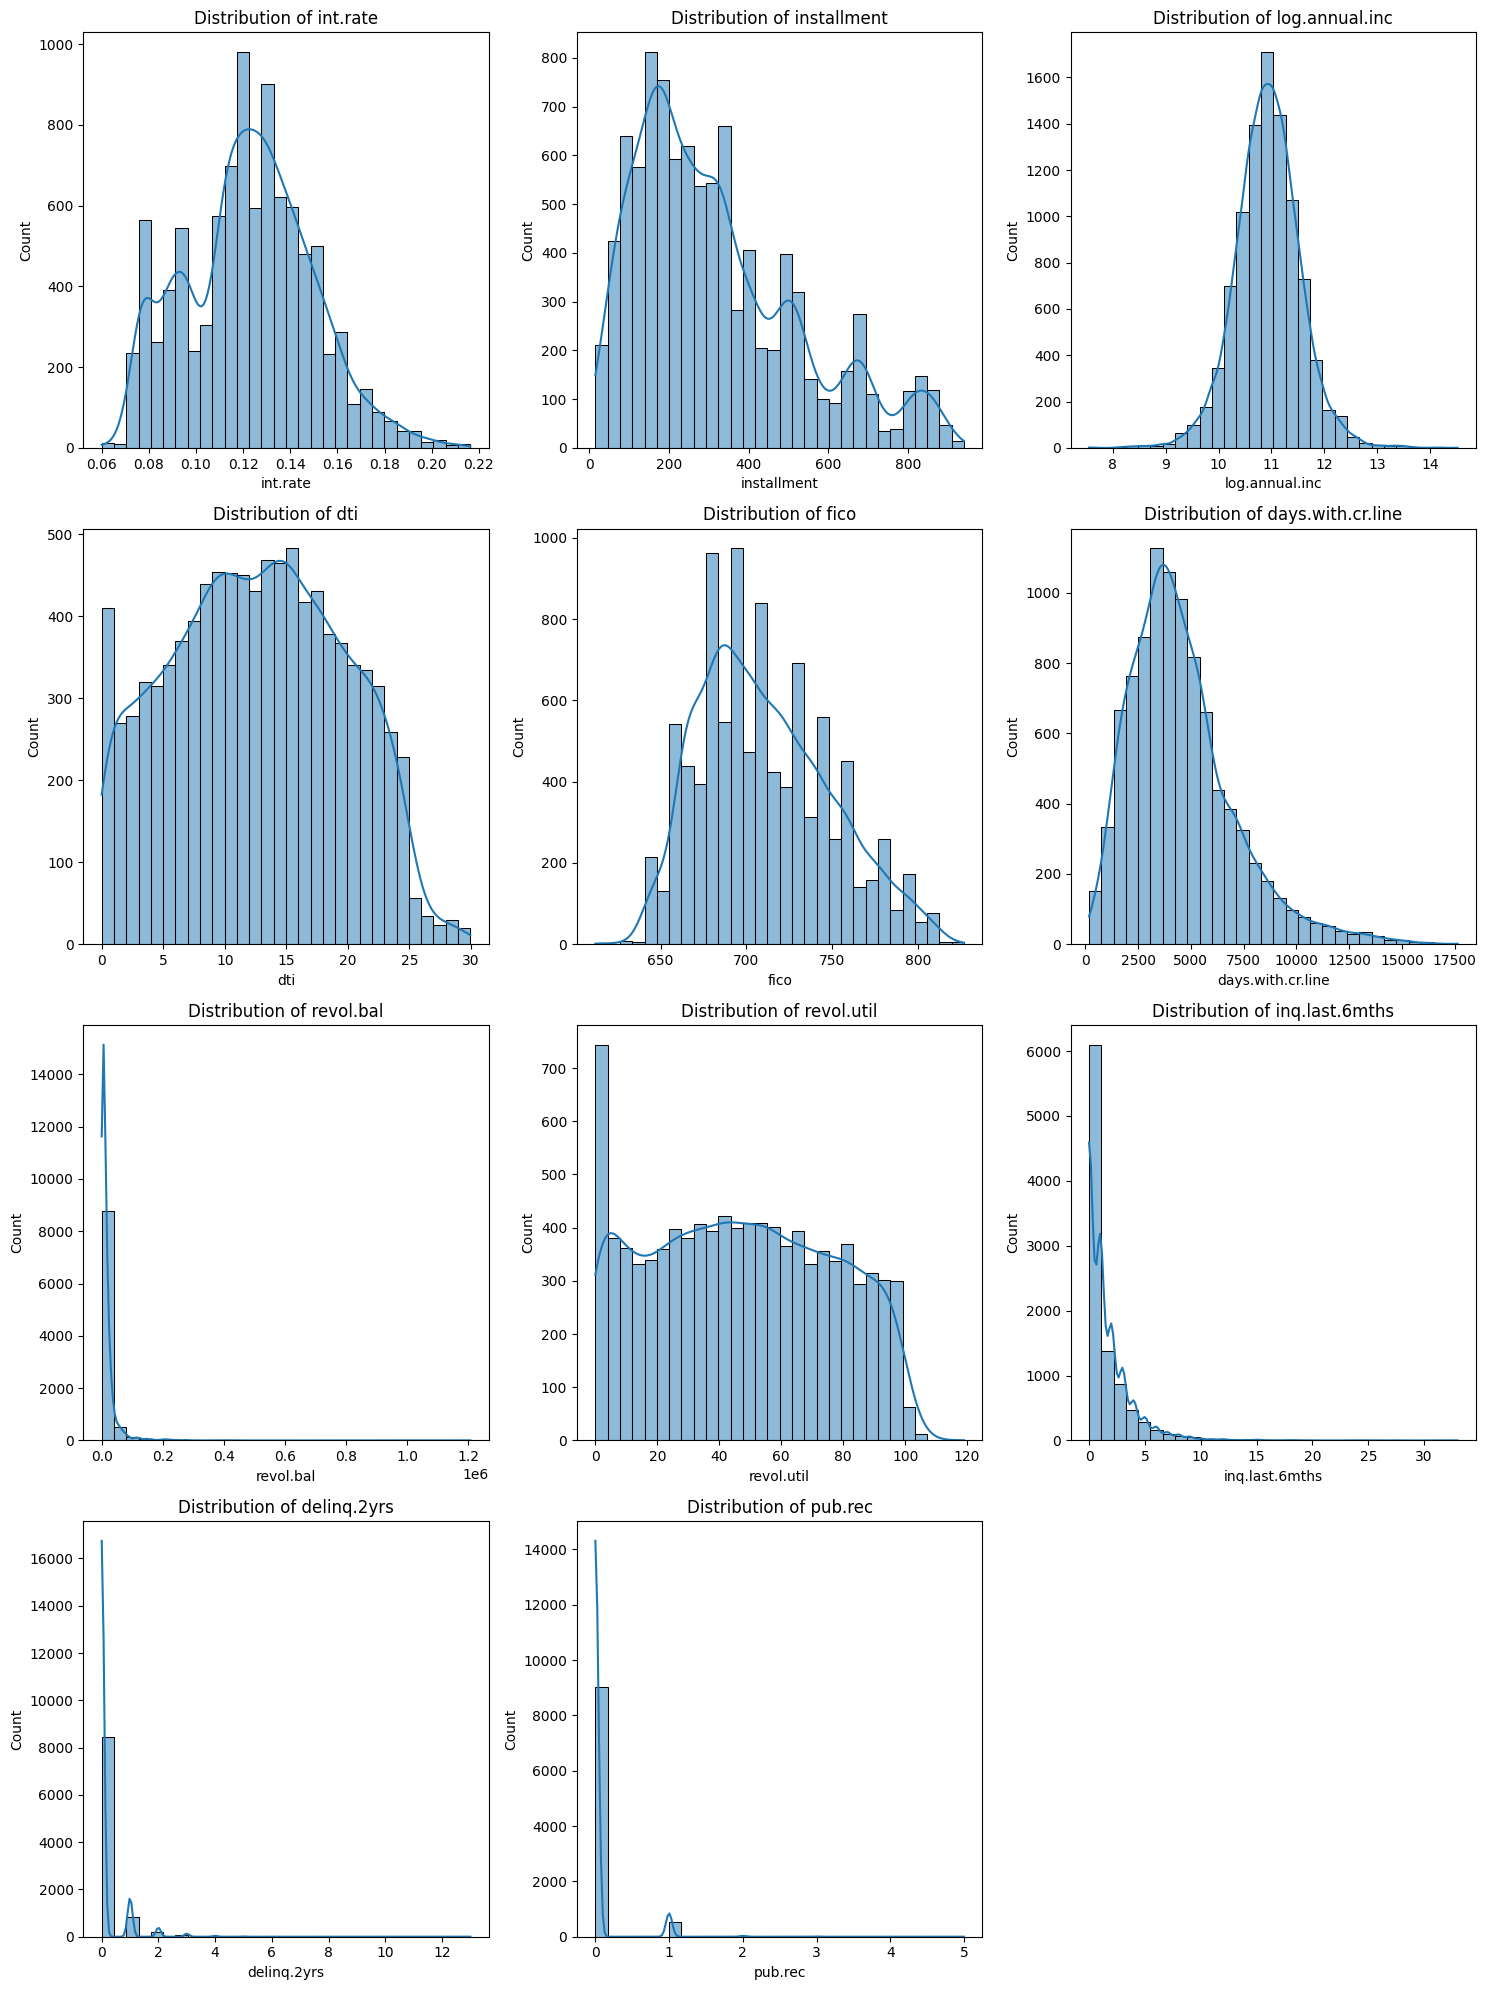

In [8]:
processor.get_histogram_plot(ignore=["credit.policy"])

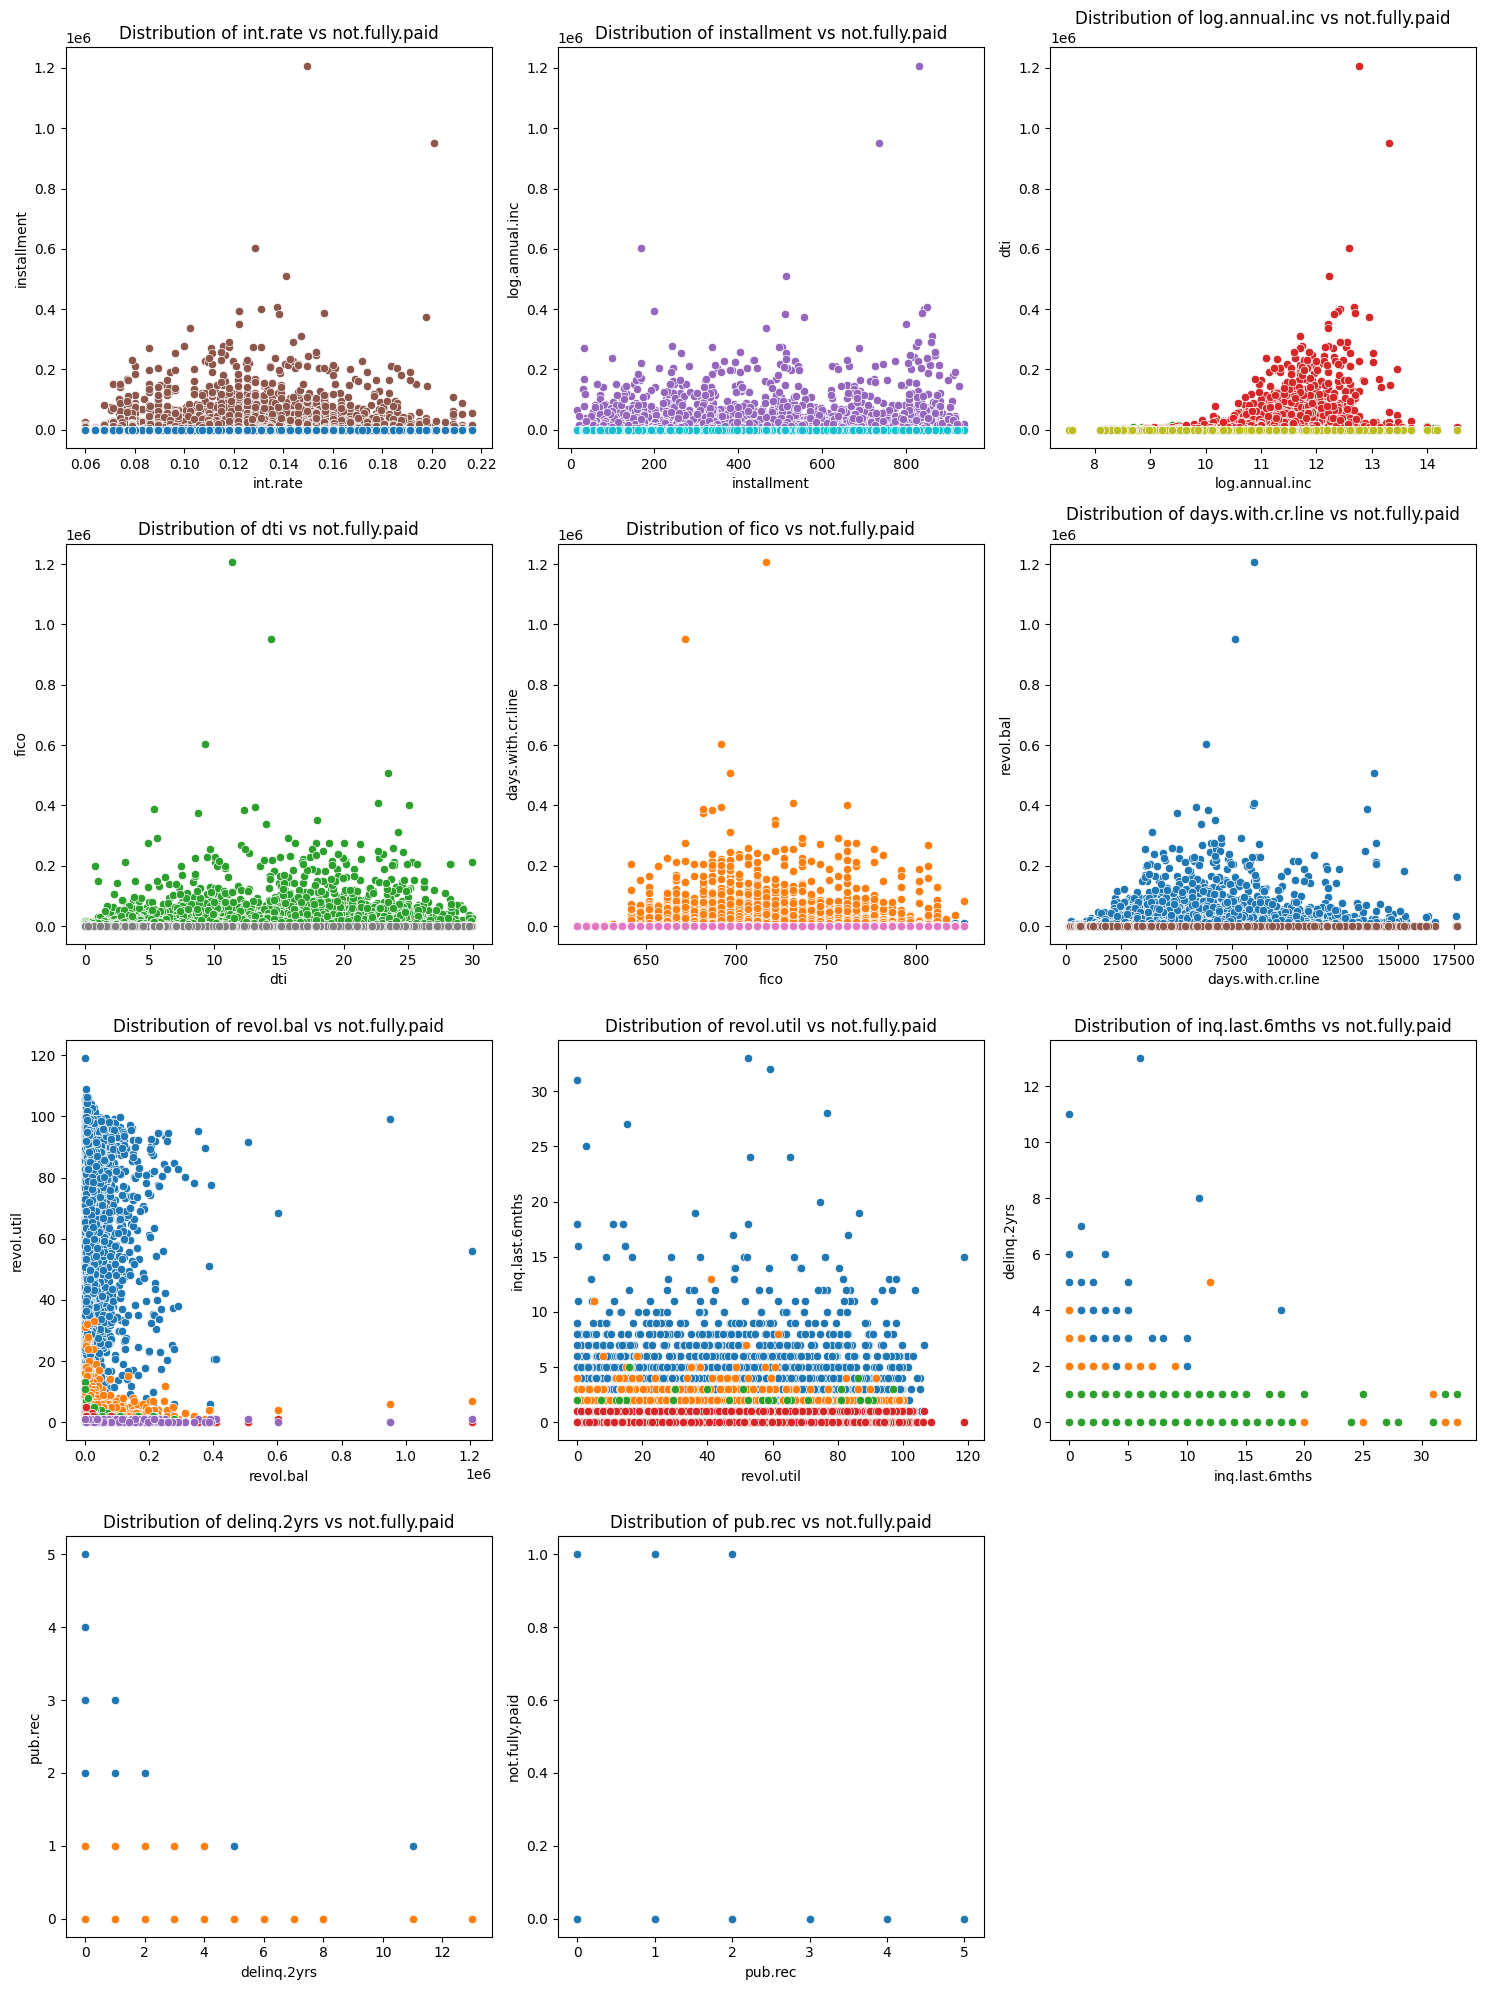

In [9]:
processor.get_scatter_plot()

## Generate Training and Testing Data

In [ ]:
scale_features = []
processor.processWithStandardScaler(inplace=False)
#print(processor.get_data().columns.tolist())

In [ ]:
processor.set_train_test_data()

print(processor.get_train_features().info())

In [ ]:
print(processor.get_test_features().info())